# PCLab#3

This notebook presents the analysis conducted for the third lab of the Finance with Big Data course. In this project, we assume the role of analysts at a sophisticated hedge fund interested in exploiting the predictive power of social media data. The objective is to analyze a dataset of financial tweets, perform text preprocessing and sentiment analysis, and construct a firm-level measure of media attention. Building on this, we investigate whether Twitter-based attention and sentiment can be used to create a meaningful investment factor and whether it is related to stock returns.

# Imports

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from collections import Counter
from datetime import datetime
import requests, bs4
import yfinance as yf
from collections import defaultdict
from tqdm import tqdm
import pandas as pd
import numpy as np
import re
import string
import pandas_datareader.data as pdr
# from pdr import data as web
import pandas_datareader.data as pdr
from pandas_datareader import data as web
import statsmodels.api as sm

# Deep learning / ML
from tensorflow.keras.layers import Dropout, LSTM, Dense, Embedding
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from xgboost import XGBClassifier
import torch
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_recall_fscore_support

# Evaluation & splitting
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Visualization
from wordcloud import WordCloud
import seaborn as sns
import matplotlib.pyplot as plt

# Transformers
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# NLP preprocessing
from nltk.stem import WordNetLemmatizer
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from ekphrasis.classes.preprocessor import TextPreProcessor
from ekphrasis.classes.tokenizer import SocialTokenizer
from ekphrasis.dicts.emoticons import emoticons

# GPT
from openai import OpenAI
import os
from getpass import getpass

pd.set_option('display.max_colwidth', 200)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
#!pip -q install --upgrade openai pandas

In [ ]:
df = pd.read_csv('./data/Data_PCLab3_Twitter_Stock_Sentiment.csv')

Mounted at /content/drive


In [ ]:
df.head()

,Text,Sentiment
0,"Kickers on my watchlist XIDE TIT SOQ PNK CPW BPZ AJ trade method 1 or method 2, see prev posts",1
1,user: AAP MOVIE. 55% return for the FEA/GEED indicator just 15 trades for the year. AWESOME.,1
2,user I'd be afraid to short AMZN - they are looking like a near-monopoly in eBooks and infrastructure-as-a-service,1
3,MNTA Over 12.00,1
4,OI Over 21.37,1


# Gathering the scraped dataset

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
resp.raise_for_status()

soup = bs4.BeautifulSoup(resp.text, "lxml")

table = soup.select_one("table#constituents")
rows = table.select("tbody tr")[1:]

tickers = []
for r in rows:
    t = r.select_one("td").get_text(strip=True)
    tickers.append(t)

tickers = [t.replace(".", "-") for t in tickers]

start = datetime(2020, 10, 5)
end   = datetime(2025, 7, 31)

data = yf.download(tickers, start=start, end=end, group_by="ticker", auto_adjust=False)

[*********************100%***********************]  503 of 503 completed


In [ ]:
df_web = (data.stack(level=0).reset_index().set_index("Date"))

df_web.columns.name = None

df_web = df_web.reset_index()
df_web.head()

/tmp/ipython-input-1048013887.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_web = (data.stack(level=0).reset_index().set_index("Date"))


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2020-10-05,A,100.989998,103.459999,100.959999,103.120003,99.675102,803900.0
1,2020-10-05,AAPL,113.910004,116.650002,113.550003,116.500000,113.321632,106243800.0
2,2020-10-05,ABBV,86.489998,88.180000,86.209999,87.930000,71.898285,5984200.0
3,2020-10-05,ABT,107.180000,108.650002,107.180000,108.559998,99.294914,3603400.0
4,2020-10-05,ACGL,30.020000,30.690001,29.680000,30.639999,29.135530,990000.0


# **Task 1**: Basic manipulation and descriptive statistics

**How many tweets?**

In [ ]:
n_tweets = len(df)
print(f"# Tweets: {n_tweets:,}")

# Tweets: 5,791


In [ ]:
df["word_count"] = (
    df["Text"]
    .str.split()
    .str.len())
df

,Text,Sentiment,word_count
0,"Kickers on my watchlist XIDE TIT SOQ PNK CPW BPZ AJ trade method 1 or method 2, see prev posts",1,20
1,user: AAP MOVIE. 55% return for the FEA/GEED indicator just 15 trades for the year. AWESOME.,1,16
2,user I'd be afraid to short AMZN - they are looking like a near-monopoly in eBooks and infrastructure-as-a-service,1,18
3,MNTA Over 12.00,1,3
4,OI Over 21.37,1,3
...,...,...,...
5786,"Industry body CII said #discoms are likely to suffer a net revenue loss of around Rs 30,000 crore\n\nhttps://t.co/8c6YJYJajL",0,19
5787,"#Gold prices slip below Rs 46,000 as #investors book profits amid #coronavirus-led #recession fears https://t.co/fSylAJrUqv",0,15
5788,Workers at Bajaj Auto have agreed to a 10% wage cut for the period between April 15 and till the lockdown is lifted. https://t.co/RgvrKPliNd,1,24
5789,"#Sharemarket LIVE: Sensex off day’s high, up 600 points, #Nifty tests 9,200, #TCS, private bank stocks lead\nhttps://t.co/3xgtLroKUI",1,18


In [ ]:
print(f"{df["word_count"].mean()}")

14.008806769124504


The dataset includes **5,971 tweets in total**, with an average of around **14 words per tweet**, indicating that messages are generally brief, a characteristic in line with Twitter's concise communication style.

**Distribution of number of words per tweets**

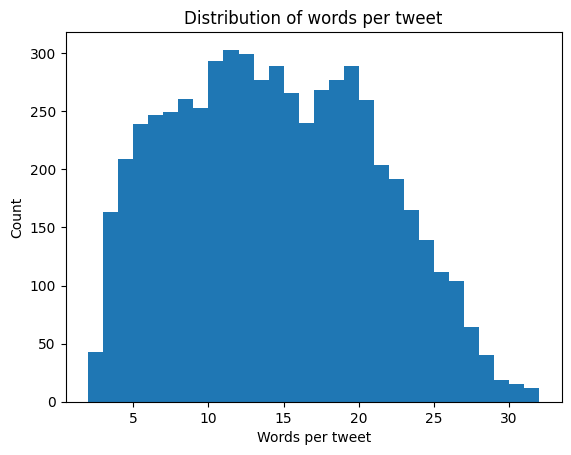

In [ ]:
plt.figure()
df["word_count"].plot(kind="hist", bins=30)
plt.xlabel("Words per tweet")
plt.ylabel("Count")
plt.title("Distribution of words per tweet")
plt.show()

The histogram above shows the distribution of the number of words per tweet, which appears to be **positively skewed**. This means that most tweets contain **between 10 and 20 words**, while longer tweets are progressively less frequent. Users tend to express their thoughts in short, direct messages, with only a minority producing more elaborate content. This confirms the inherently **brief nature of interactions on the platform**.

**Average Sentiment**

In [ ]:
avg_sent= df["Sentiment"].mean()
print(f"Average sentiment: {avg_sent:.4f}")

Average sentiment: 0.6363


The **average sentiment** score of **0.6363** suggests that the tweets in the dataset are, on average, **moderately positive** in tone. This implies that users tend to post content with a generally favorable attitude.

**Character count**

In [ ]:
df["char_count"] = df["Text"].astype(str).str.len()
print("\nCharacters per tweet (summary):")
print(df["char_count"].describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_string())


Characters per tweet (summary):
count    5791.000000
mean       78.507857
std        37.409135
min         6.000000
25%        48.000000
50%        79.000000
75%       106.000000
90%       133.000000
95%       141.000000
99%       144.000000
max       154.000000


The **average length of 78.5 characters per tweet** confirms that the messages are fairly concise, in line with our previous findings in terms of average number of words per tweet.

**Hashtags and Mentions**


Top hashtags:
Text
#nifty            28
#sensex           28
#marketupdates    26
#13for2013        14
#fed               8
#2                 7
#1                 7
#stocks            6
#apple             4
#technology        3
#cloud             3
#3weekstight       2
#android           2
#3                 2
#s                 2


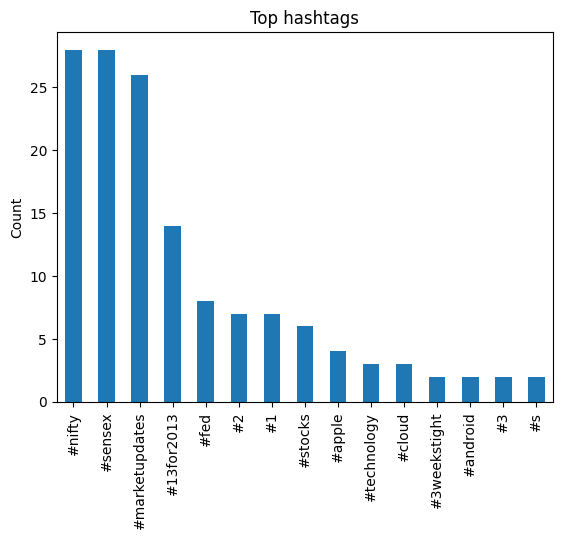


Top mentions:
Text
@wsjheard          9
@wsj               8
@joannechiuhk      6
@birdyword         6
@jchengwsj         6
@lizrhoffman       5
@djtgallagher      5
@jonsindreu        4
@srussolillo       4
@amrithramkumar    3
@sarahtoy17        3
@kosakunarioka     3
@jasonzweigwsj     3
@jdlahart          3
@pauljdavies       3


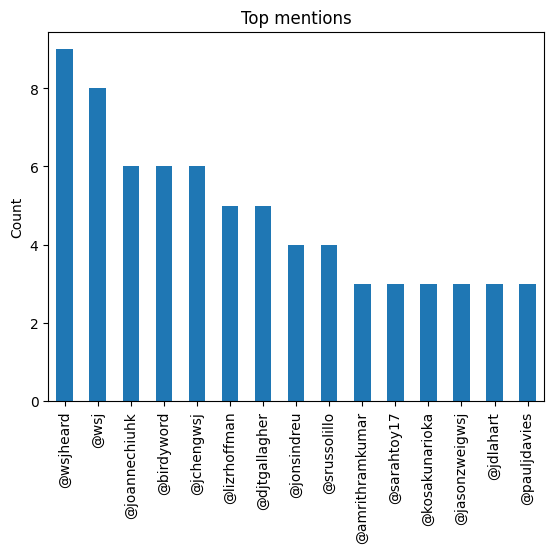

In [ ]:
# Top hashtags & mentions
top_hashtags = (df["Text"].astype(str).str.findall(r"#\w+").explode().str.lower().dropna()
    .value_counts().head(15))

print("\nTop hashtags:")
print(top_hashtags.to_string())
plt.figure(); top_hashtags.plot(kind="bar"); plt.title("Top hashtags"); plt.ylabel("Count"); plt.xlabel("")
plt.show()

top_mentions = (df["Text"].astype(str).str.findall(r"@\w+").explode().str.lower().dropna()
    .value_counts().head(15))

print("\nTop mentions:")
print(top_mentions.to_string())
plt.figure(); top_mentions.plot(kind="bar"); plt.title("Top mentions"); plt.ylabel("Count"); plt.xlabel("")
plt.show()

The most frequent hashtags (#nifty, #sensex, and #marketupdates) point to an active **focus on Indian financial markets**, specifically the Nifty 50 and Sensex indices. User likely used them to discuss daily market movements and stock trends, commenting on financial updates. The presence of #fed as fifth most recurring hashtag, draws also attention to monetary policy and macroeconomic factors. This is reasonable since decisions from the **U.S. Federal Reserve** are known to affect global markets. Other hashtags such as #stocks, #apple, #technology, and #cloud show that discussions occasionally extend to individual stocks and the tech sector, reflecting the relevance of global tech companies within financial market discourse. Meanwhile, tags like #13for2013 and #3weekstight might refer to specific campaigns, market outlooks, or investment themes from that period, showing user engagment to also **short-term events**.

The top mentions further confirm this financial orientation. Many of the most cited accounts, including @wsjheard, @wsj, @jchengwsj, @lizrhoffman, and @jonsindreu, belong to **Wall Street Journal journalists and editors**, suggesting that users actively interact with financial media and expert commentary, often referencing formal sources to discuss recent market updates.

# **Task 2**: Cleaning and Visualization

## Data Cleaning

We clean each tweet by defining a function called `clean_text` that will:
* Convert everything to lowercase
* Remove URLs, mentions, and punctuation
* Drop stopwords and very short tokens
* Apply lemmatization to reduce words to their base form

The processed version of the column `Text` will be stored in a new column called `clean_text_manual`.

In [ ]:
# Precompiled regex patterns
_punct_pattern   = re.compile(rf"[{re.escape(string.punctuation)}]")
_url_pattern     = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
_mention_pattern = re.compile(r"@\w+")
_hashtag_pattern = re.compile(r"#")
_digit_pattern   = re.compile(r"\d+")
_whitespace      = re.compile(r"\s+")

# Stopwords + lemmatizer
_stop = set(stopwords.words("english"))
_lemma = WordNetLemmatizer()
_custom_drop = {"rt", "amp"}


def normalize_token(tok: str) -> str:
    if not tok or len(tok) <= 2:
        return ""
    if tok.isdigit():
        return ""
    tok = _digit_pattern.sub("", tok)
    return _lemma.lemmatize(tok) if tok else ""

def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    txt = str(text).lower()
    txt = _url_pattern.sub(" ", txt)
    txt = _mention_pattern.sub(" ", txt)
    txt = _hashtag_pattern.sub(" ", txt)
    txt = _punct_pattern.sub(" ", txt)
    tokens = _whitespace.split(txt.strip())

    cleaned = []
    for t in tokens:
        if not t or t in _stop or t in _custom_drop:
            continue
        nt = normalize_token(t)
        if nt and nt not in _stop and nt not in _custom_drop:
            cleaned.append(nt)
    return " ".join(cleaned)

In [ ]:
df = df.copy()
df["clean_text_manual"] = df["Text"].astype(str).apply(clean_text)

df[["Text", "Sentiment", "clean_text_manual"]].head(10)

,Text,Sentiment,clean_text_manual
0,"Kickers on my watchlist XIDE TIT SOQ PNK CPW BPZ AJ trade method 1 or method 2, see prev posts",1,kicker watchlist xide tit soq pnk cpw bpz trade method method see prev post
1,user: AAP MOVIE. 55% return for the FEA/GEED indicator just 15 trades for the year. AWESOME.,1,user aap movie return fea geed indicator trade year awesome
2,user I'd be afraid to short AMZN - they are looking like a near-monopoly in eBooks and infrastructure-as-a-service,1,user afraid short amzn looking like near monopoly ebooks infrastructure service
3,MNTA Over 12.00,1,mnta
4,OI Over 21.37,1,
5,PGNX Over 3.04,1,pgnx
6,AAP - user if so then the current downtrend will break. Otherwise just a short-term correction in med-term downtrend.,0,aap user current downtrend break otherwise short term correction med term downtrend
7,Monday's relative weakness. NYX WIN TIE TAP ICE INT BMC AON C CHK BIIB,0,monday relative weakness nyx win tie tap ice int bmc aon chk biib
8,GOOG - ower trend line channel test & volume support.,1,goog ower trend line channel test volume support
9,AAP will watch tomorrow for ONG entry.,1,aap watch tomorrow ong entry


An alternative way to effectively clean our dataset relies on the **Ekphrasis library** implemented in Python. Its main advantage relies in the fact that it was **designed specifically for social media text**. For this reason, unlike manual cleaning, it can normalize URLs, mentions, hashtags, numbers, and dates, split hashtags into words, and so on while considering the context of each word and trying to preserve its meaning as much as possible.
The processed version of the column `Text`, with the use of the Ekphrasis library, will be stored in a new column called `clean_text`.

In [ ]:
# Ekphrasis preprocessor
text_processor = TextPreProcessor(
    normalize=['url', 'email', 'percent', 'money', 'phone', 'user', 'time', 'date', 'number'],
    annotate={"hashtag", "allcaps", "elongated", "repeated", "emphasis", "censored"},
    fix_html=True,
    segmenter="twitter",           # splits hashtags into words
    corrector="twitter",           # fixes common Twitter misspellings
    unpack_hashtags=True,
    unpack_contractions=True,
    spell_correct_elong=True,
    tokenizer=SocialTokenizer(lowercase=True).tokenize,
    dicts=[emoticons])

def clean_text_ekphrasis_no_punct(text: str):
    if pd.isna(text):
        return ""
    tokens = text_processor.pre_process_doc(text)
    cleaned = []
    for tok in tokens:
        tok = tok.lower().strip()
        if tok in _stop or tok in _custom_drop:
            continue
        if tok.startswith("<") and tok.endswith(">"):
            continue
        if tok in string.punctuation:
            continue
        nt = _lemma.lemmatize(tok)
        if nt and nt not in _stop and nt not in _custom_drop:
            cleaned.append(nt)
    return " ".join(cleaned)

df["clean_text"] = df["Text"].apply(clean_text_ekphrasis_no_punct)

/usr/local/lib/python3.12/dist-packages/ekphrasis/classes/tokenizer.py:225: FutureWarning: Possible nested set at position 2190
  self.tok = re.compile(r"({})".format("|".join(pipeline)))


Word statistics files not found!
Downloading... done!
Unpacking... done!
Reading twitter - 1grams ...
generating cache file for faster loading...
reading ngrams /root/.ekphrasis/stats/twitter/counts_1grams.txt
Reading twitter - 2grams ...
generating cache file for faster loading...
reading ngrams /root/.ekphrasis/stats/twitter/counts_2grams.txt


/usr/local/lib/python3.12/dist-packages/ekphrasis/classes/exmanager.py:14: FutureWarning: Possible nested set at position 42
  regexes = {k.lower(): re.compile(self.expressions[k]) for k, v in


Reading twitter - 1grams ...


From now on, for the reasons aforementioned, in our elaborations we will leverage the Ekphrasis output.

## Generating Word Clouds by Sentiment

Within the following section, to better understand the vocabulary associated with positive and negative sentiment (as classified in the given column `Sentiment`), we create two word clouds and plot them side by side:
- On the **left:** we have the Negative sentiment (label 0).
- On the **right:** Positive sentiment (label 1).


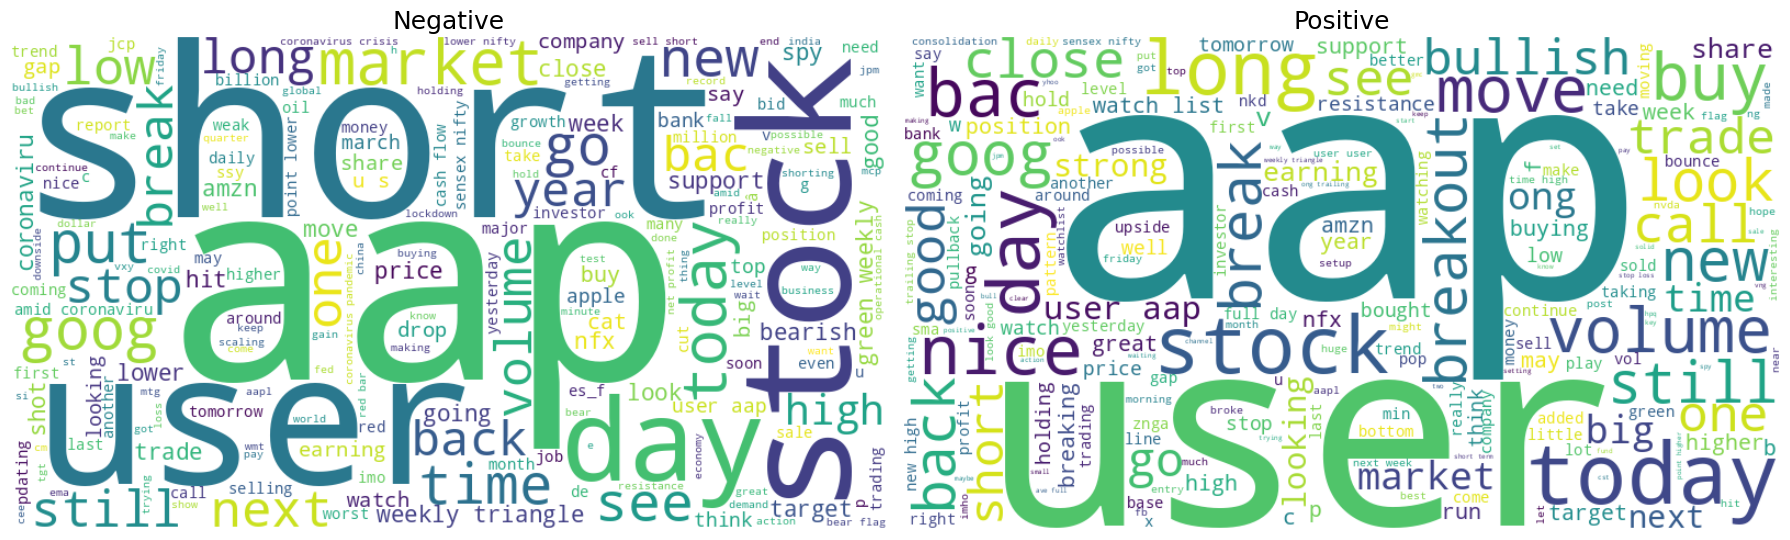

In [ ]:
def build_cloud(text_series: pd.Series) -> WordCloud:
    combined = " ".join(text_series.astype(str)) #.dropna()
    return WordCloud(width=800, height=450, max_words=200, background_color="white").generate(combined)


sent_map = {0: "Negative", 1: "Positive"}
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, label in enumerate([0, 1]):
    subset = df.loc[df["Sentiment"] == label, "clean_text"]
    wc = build_cloud(subset)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].axis("off")
    axes[idx].set_title(sent_map[label], fontsize=18)

plt.tight_layout()
plt.show()

The patterns revealed in the word clouds for positive and negative sentiment align with the language and behaviour observed in financial markets. More in detail, in the negative sentiment cloud, terms like **"short," "low," and "stop" stand out**, each pointing to expectations of declining prices and **pessimistic outlooks**. On the other hand, the positive sentiment cloud emphasizes words such as **"long," "buy," and "bullish,"** which carry an optimistic tone. These words are consistent with a **positive perspective, where investors foresee upward momentum** and stronger performance.   

Taken together, these associations highlight the **strong relationship between the terminology used in short texts** (tweets, posts, or headlines) and the **underlying market sentiment they reflect**.  
The visual representation makes it clear how certain words act as signals of either confidence or caution within the trading environment.  

## Identifying Rare Terms

We now check which tokens occur only once across the dataset, to spot potential noise in the data.


In [ ]:
token_counts = Counter()
for row in df["clean_text"].dropna():
    token_counts.update(row.split())

rare_terms = [w for w, c in token_counts.items() if c == 1]

print(f"Number of unique tokens appearing only once: {len(rare_terms)}")

rare_df = (
    pd.DataFrame({"token": list(token_counts.keys()), "freq": list(token_counts.values())})
    .sort_values("freq")
    .reset_index(drop=True))
rare_df.head(10)

Number of unique tokens appearing only once: 3839


,token,freq
0,bpz,1
1,pnk,1
2,soq,1
3,cii,1
4,iafter,1
5,comparison,1
6,bleeds,1
7,bailing,1
8,poxy,1
9,sour,1


In [ ]:
num_rare_terms = len(rare_df[rare_df['freq'] == 1])
total_word_occurrences = rare_df['freq'].sum()
total_unique_words = len(rare_df)

print(f"Number of rare terms (frequency == 1): {num_rare_terms}")
print(f"Total number of word occurrences: {total_word_occurrences}")
print(f"Total number of unique words: {total_unique_words}")

percentage_rare_of_total_occurrences = (num_rare_terms / total_word_occurrences) * 100 if total_word_occurrences > 0 else 0
percentage_rare_of_unique_words = (num_rare_terms / total_unique_words) * 100 if total_unique_words > 0 else 0

print(f"Percentage of rare terms out of total word occurrences: {percentage_rare_of_total_occurrences:.2f}%")
print(f"Percentage of rare terms out of total unique words: {percentage_rare_of_unique_words:.2f}%")

Number of rare terms (frequency == 1): 3839
Total number of word occurrences: 51629
Total number of unique words: 7605
Percentage of rare terms out of total word occurrences: 7.44%
Percentage of rare terms out of total unique words: 50.48%


The output shows that **3,839 tokens appear only once in the dataset**. This relatively large number indicates a high lexical diversity, but also reflects the noisy and informal nature typical of Twitter text. These tokens account for about **50% of the 7,605 unique words**, yet represent only 7.44% of the total word occurrences. Considering these factors, along with the brevity of tweets, we decided not to filter out these rare terms. In fact many of them may function as **low-frequency but high-impact tokens**, contributing significantly to meaning of each text. Therefore, removing them could negatively affect the overall interpretation and sentiment of the tweets.

# **Task 3**: Sentiment Analysis

This section evaluates the reliability of provided sentiment labels, contained the column `Sentiment`, for our stock-related tweets by **comparing them against predictions from pretrained transformer models**.

In [ ]:
tweets = df.copy()
tweets['clean_text'] = tweets['clean_text'].replace(
    {r'^\s*$': np.nan, r'^(?:nan|none|null)$': np.nan}, regex=True)

before = len(tweets)
tweets = tweets.dropna(subset=['clean_text', 'Sentiment']).copy()
tweets = tweets.reset_index(drop=True)
print(f"Dropped {before - len(tweets)} rows with empty/NA clean_text or Sentiment.")
tweets[['clean_text','Sentiment']].sample(5, random_state=42)

Dropped 2 rows with empty/NA clean_text or Sentiment.


,clean_text,Sentiment
3346,user goog gonna take 2 x aap shortly split stock 1 0 x accurate penis measurement,1
4740,eps 1 st tgt bounce possible extension later,1
1049,looking c potential bounce play w aap earnings imo aap eps even guidance key,0
1700,know yhoo month january,1
156,watch close carefully decide whether ong shot aap shot,0


## Twitter-RoBERTa

In the following section, we focus on the **pretrained Twitter-RoBERTa** model, loading its tokenizer and configuration. This model is widely recognized in NLP as being particularly well suited for social media text, as it was **trained on a large corpus of tweets** characterized by brief, informal, and noisy language.

In [ ]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device).eval()

# Inspect label mapping
id2label = model.config.id2label
label2id = {v:k for k,v in id2label.items()}
id2label

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


{0: 'negative', 1: 'neutral', 2: 'positive'}

In [ ]:
def predict_probs(texts, batch_size=64, max_length=128):
    """Return per-class probabilities for each text."""
    probs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Scoring"):
        batch = texts[i:i+batch_size].tolist()
        enc = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors='pt').to(device)
        with torch.no_grad():
            logits = model(**enc).logits
            if logits.shape[1] == 1:
                # (rare) binary models with single-logit; convert to 2-class probs
                p_pos = torch.sigmoid(logits).squeeze(1)
                p = torch.stack([1 - p_pos, p_pos], dim=1)
            else:
                p = torch.softmax(logits, dim=1)
        probs.append(p.detach().cpu().numpy())
    return np.vstack(probs)

probs = predict_probs(tweets['clean_text'])
probs[:3], probs.shape


Scoring: 100%|██████████| 91/91 [11:07<00:00,  7.33s/it]


(array([[0.04559951, 0.9051864 , 0.04921406],
        [0.00369229, 0.05603908, 0.9402686 ],
        [0.51462716, 0.45354557, 0.03182728]], dtype=float32),
 (5789, 3))

As one can see above, **unlike binary classifiers**, Twitter-RoBERTa produces **three sentiment labels** (negative, neutral, and positive).

Therefore,to align its output with the given one stored in the `Sentiment` column (0 and 1)and to be able to operate a comparison between them, we implement **3 different strategies**:

- **Strategy A**: We only keep tweets where $$ argmax \{p_{neg}, p_{neu}, p_{pos}\} \neq neutral $$ Meaning that if the highest probability given by the model is neutral, we discard that tweet. On the retrained dataset we then predict $ \hat{y} = 1 \{p_{pos} \geq 0.5 \} $.
- **Strategy B**: We predict $$
\hat{y} =
\begin{cases}
10, & \text{if } \arg\max\{p_{\text{neg}}, p_{\text{neu}}, p_{\text{pos}}\} = \text{positive}, \\
0,  & \text{otherwise (negative or neutral)}.
\end{cases} $$
So both **negative** and **neutral** map to 0.

- **Strategy C**: We compare only the probability of the tweet being positive or negative and predict $$ \hat{y} = 1\{\,p_{\text{pos}} \geq p_{\text{neg}}\,\}$$So we ignore the neutral mass and compare only **positive** vs **negative**. We label a tweet positive when its positive probability is at least as large as its negative probability.

In [ ]:
# Create a df of model outputs
labels = [id2label[i].lower() for i in range(len(id2label))]
probs_df = pd.DataFrame(probs, columns=labels)

def find_col(candidates):
    for c in candidates:
        for col in probs_df.columns:
            if c in col.lower():
                return col
    return None

col_pos = find_col(["pos","positive"])
col_neg = find_col(["neg","negative"])
col_neu = find_col(["neu","neutral"])

# Fallback if a strictly binary model:
if col_neu is None and len(probs_df.columns)==2:
    col_neg = probs_df.columns[0] if col_neg is None else col_neg
    col_pos = probs_df.columns[1] if col_pos is None else col_pos

# Predicted class (argmax over available columns)
probs_df['pred_label'] = probs_df[[c for c in [col_neg, col_neu, col_pos] if c is not None]].idxmax(axis=1)


def map_probs_to_binary_closest(probs: np.ndarray) -> np.ndarray:
    if probs.ndim != 2:
        raise ValueError("Expected 2D array (n_samples, n_classes).")
    n_classes = probs.shape[1]
    if n_classes == 3:
        return (probs[:, 2] >= probs[:, 0]).astype(int)
    elif n_classes == 2:
        return (probs[:, 1] >= probs[:, 0]).astype(int)
    else:
        raise ValueError(f"Unsupported number of classes: {n_classes}")

# Strategy A: drop neutrals
mask_non_neu = probs_df['pred_label'] != col_neu if col_neu is not None else np.ones(len(probs_df), dtype=bool)
y_true_A = tweets.loc[mask_non_neu, 'Sentiment'].values
y_prob_pos_A = probs_df.loc[mask_non_neu, col_pos].values if col_pos is not None else probs_df.loc[mask_non_neu, probs_df.columns[-1]].values
y_pred_A = (y_prob_pos_A >= 0.5).astype(int)

# Strategy B: map neutral -> 0
y_true_B = tweets['Sentiment'].values.copy()
y_prob_pos_B = probs_df[col_pos].values if col_pos is not None else probs_df[probs_df.columns[-1]].values
y_pred_B = (probs_df['pred_label'].replace({col_pos:1, col_neg:0, col_neu:0}).fillna(0).astype(int)).values

# Strategy C: Closest-Side (pos ≥ neg)
y_true_C = tweets['Sentiment'].to_numpy()
y_prob_pos_C = probs_df[col_pos].to_numpy()
y_pred_C = (probs_df[col_pos].to_numpy() >= probs_df[col_neg].to_numpy()).astype(int)

/tmp/ipython-input-442654893.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_pred_B = (probs_df['pred_label'].replace({col_pos:1, col_neg:0, col_neu:0}).fillna(0).astype(int)).values


=== cardiffnlp/twitter-roberta-base-sentiment-latest — Binary-DroppedNeutral ===
Accuracy: 0.787 | Precision: 0.860 | Recall: 0.783 | F1: 0.820 | AUROC: 0.821

Classification report:
              precision    recall  f1-score   support

           0      0.694     0.794     0.741       626
           1      0.860     0.783     0.820      1011

    accuracy                          0.787      1637
   macro avg      0.777     0.789     0.780      1637
weighted avg      0.797     0.787     0.790      1637



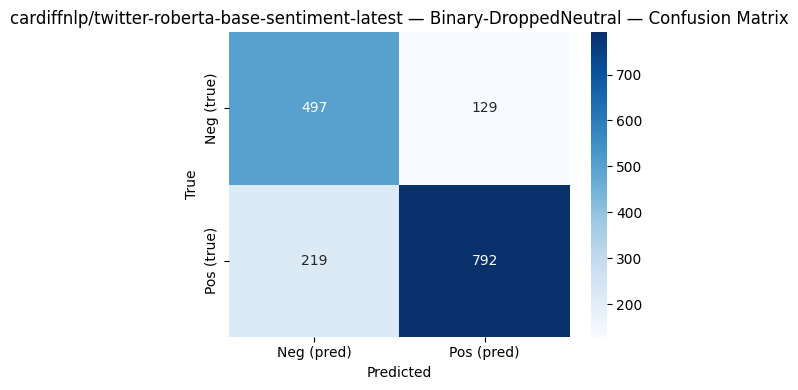

=== cardiffnlp/twitter-roberta-base-sentiment-latest — Binary-NeutralAsNegative ===
Accuracy: 0.480 | Precision: 0.855 | Recall: 0.219 | F1: 0.349 | AUROC: 0.708

Classification report:
              precision    recall  f1-score   support

           0      0.406     0.935     0.567      2106
           1      0.855     0.219     0.349      3683

    accuracy                          0.480      5789
   macro avg      0.631     0.577     0.458      5789
weighted avg      0.692     0.480     0.428      5789



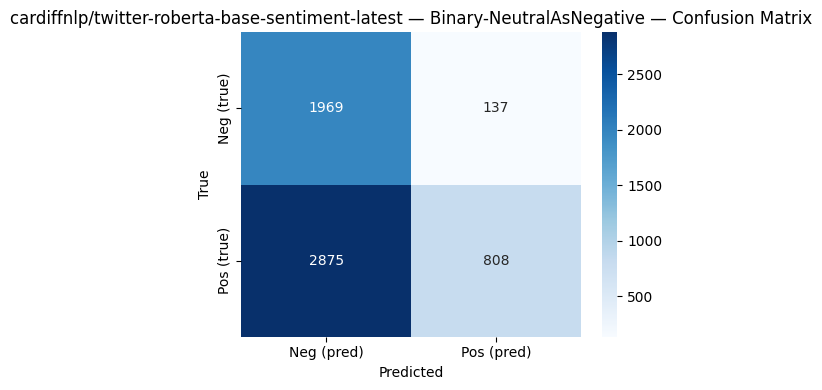

=== cardiffnlp/twitter-roberta-base-sentiment-latest — Binary-ClosestSide ===
Accuracy: 0.671 | Precision: 0.747 | Recall: 0.731 | F1: 0.739 | AUROC: 0.708

Classification report:
              precision    recall  f1-score   support

           0      0.547     0.567     0.557      2106
           1      0.747     0.731     0.739      3683

    accuracy                          0.671      5789
   macro avg      0.647     0.649     0.648      5789
weighted avg      0.674     0.671     0.673      5789



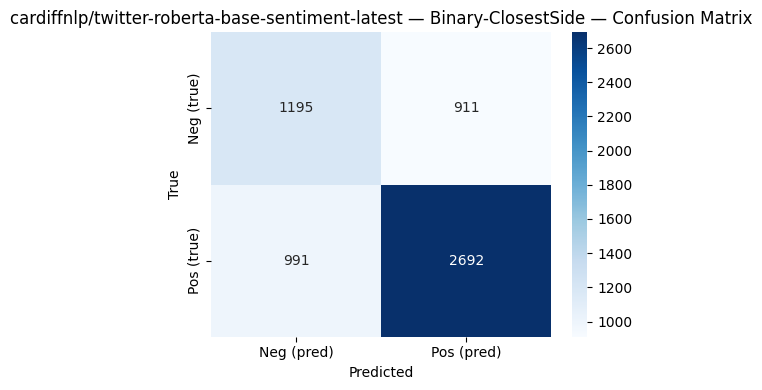

In [ ]:
def evaluate(y_true, y_pred, y_prob_pos, title=""):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        auroc = roc_auc_score(y_true, y_prob_pos)
    except Exception:
        auroc = np.nan

    print(f"=== {title} ===")
    print(f"Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f} | AUROC: {auroc:.3f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg (pred)','Pos (pred)'],
                yticklabels=['Neg (true)','Pos (true)'])
    plt.title(title + " — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.show()

evaluate(y_true_A, y_pred_A, y_prob_pos_A, title=f"{MODEL_NAME} — Binary-DroppedNeutral")
evaluate(y_true_B, y_pred_B, y_prob_pos_B, title=f"{MODEL_NAME} — Binary-NeutralAsNegative")
evaluate(y_true_C, y_pred_C, y_prob_pos_C, title=f"{MODEL_NAME} — Binary-ClosestSide")

In [ ]:
results = pd.DataFrame(columns=['model','metric_setting','n_eval','accuracy','f1'])
# Save summary from the current run (execute this after each model run)
result_row = {
    'model': MODEL_NAME,
    'metric_setting': 'DroppedNeutral',
    'n_eval': int(len(y_true_A)),
    'accuracy': float(accuracy_score(y_true_A, y_pred_A)),
    'f1': float(precision_recall_fscore_support(y_true_A, y_pred_A, average='binary', zero_division=0)[2]),}
result_row2 = {
    'model': MODEL_NAME,
    'metric_setting': 'NeutralAsNegative',
    'n_eval': int(len(y_true_B)),
    'accuracy': float(accuracy_score(y_true_B, y_pred_B)),
    'f1': float(precision_recall_fscore_support(y_true_B, y_pred_B, average='binary', zero_division=0)[2]),}

result_row3 = {
    'model': MODEL_NAME,
    'metric_setting': 'ClosestSide',
    'n_eval': int(len(y_true_C)),
    'accuracy': float(accuracy_score(y_true_C, y_pred_C)),
    'f1': float(precision_recall_fscore_support(y_true_C, y_pred_C, average='binary', zero_division=0)[2]),}

# Append all three
try:
    results = pd.concat([results, pd.DataFrame([result_row, result_row2, result_row3])], ignore_index=True)
except NameError:
    results = pd.DataFrame([result_row, result_row2, result_row3])

results

/tmp/ipython-input-3236153392.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([result_row, result_row2, result_row3])], ignore_index=True)


,model,metric_setting,n_eval,accuracy,f1
0,cardiffnlp/twitter-roberta-base-sentiment-latest,DroppedNeutral,1637,0.787416,0.819876
1,cardiffnlp/twitter-roberta-base-sentiment-latest,NeutralAsNegative,5789,0.479703,0.349179
2,cardiffnlp/twitter-roberta-base-sentiment-latest,ClosestSide,5789,0.671446,0.738951


Results:
- **Strategy A** achieves the highest F1 (**0.819**), but on a reduced filtered subset (29.8% coverage).
- **Strategy B** collapses neutral into 0, yielding high precision, but very low recall for the positive class (F1 **0.349** overall).
- **Strategy C** provides the best performance on the full dataset with balanced precision/recall (F1 **0.738**, coverage 100%).

For these reasons we decide to keep strategy C.

In [ ]:
tweets['pred_label_RoBERTa'] = y_pred_C
tweets.head()

,Text,Sentiment,word_count,char_count,clean_text_manual,clean_text,pred_label_RoBERTa
0,"Kickers on my watchlist XIDE TIT SOQ PNK CPW BPZ AJ trade method 1 or method 2, see prev posts",1,20,95,kicker watchlist xide tit soq pnk cpw bpz trade method method see prev post,kicker watchlist xide tit soq pnk cpw bpz aj trade method method see prev post,1
1,user: AAP MOVIE. 55% return for the FEA/GEED indicator just 15 trades for the year. AWESOME.,1,16,95,user aap movie return fea geed indicator trade year awesome,user aap movie return fea geed indicator trade year awesome,1
2,user I'd be afraid to short AMZN - they are looking like a near-monopoly in eBooks and infrastructure-as-a-service,1,18,114,user afraid short amzn looking like near monopoly ebooks infrastructure service,user afraid short amzn looking like near monopoly ebooks infrastructure service,0
3,MNTA Over 12.00,1,3,17,mnta,mnta,1
4,OI Over 21.37,1,3,16,,oi,1


## GPT

In [ ]:
#os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


In [ ]:
#tweets.sample(8, random_state=42) #tweets used as few shot examples

,Text,Sentiment,word_count,char_count,clean_text,pred_label_RoBERTa
1886,GOOG this market leader continues to hold up well,1,9,51,goog market leader continues hold well,1
3103,HBAN Huntington Bank stop loss in 6.96 ater beating 7.03,1,10,56,hban huntington bank stop loss ater beating,0
5303,The March jobs report shows the start of a collapse that could shed all the U.S. jobs added by employers in the pasâ€¦ https://t.co/pCJLsr1UJS,0,24,142,march job report show start collapse could shed job added employer pasâ€¦,0
4063,Watch NP here under 138.93 could be a nice short. And There goes CIEN under 17.11.,0,16,82,watch could nice short go cien,1
156,"JCP Keep an eye on this triangle. big short int, 34%. reports Feb 27. cup & handle. at DT. ong",1,20,96,jcp keep eye triangle big short int report feb cup handle ong,1
4852,AAP big time drop today on a day when market is up SPY,0,13,54,aap big time drop today day market spy,0
3827,SK Whoa! Somebody has some confidence in SK :) TO DA MOOOOONNNN!!!!,1,12,68,whoa somebody confidence mooooonnnn,1
3410,MS Morgan Stanley Option Bull bets 1.6 Million on an up move by July,1,14,70,morgan stanley option bull bet million move july,1


In [ ]:
# #client = OpenAI()

# #FEW_SHOTS = [
#     ("GOOG this market leader continues to hold up well	", 1),
#     ("HBAN Huntington Bank stop loss in 6.96 ater beating 7.03", 1),
#     ("The March jobs report shows the start of a collapse that could shed all the U.S. jobs added by employers", 0),
#     ("Watch NP here under 138.93 could be a nice short. And There goes CIEN under 17.11.", 0),
#     ("JCP Keep an eye on this triangle. big short int, 34%. reports Feb 27. cup & handle. at DT. ong", 1),
#     ("AAP big time drop today on a day when market is up SPY", 0),
#     ("SK Whoa! Somebody has some confidence in SK :) TO DA MOOOOONNNN!!!!", 1),
#     ("MS Morgan Stanley Option Bull bets 1.6 Million on an up move by July", 1),]

# INSTRUCTION = """You label short finance/stock tweets as binary sentiment.
# Output ONLY one character:
# - 1 = clearly positive for the stock (beats, raised guidance, upgrades, buyback, bullish momentum)
# - 0 = negative or not clearly positive (misses, cuts, downgrades, investigations, layoffs, neutral/unclear)

# Rules:
# - Treat sarcasm as negative.
# - Respect negation (e.g., "not bad" is positive).
# - If the tweet is neutral/unclear, output 0.
# - Output must be exactly '0' or '1' with nothing else.
# """

# def build_prompt(text: str) -> str:
#     examples = "\n".join([f'Post: "{t}"\nLabel: {y}' for t, y in FEW_SHOTS])
#     return f"""{INSTRUCTION}

# Examples:
# {examples}

# Now annotate this post. Reply with 0 or 1 only.
# Post: "{text}"
# Label:"""

# def call_llm(prompt: str) -> str:
#     r = client.chat.completions.create(
#         model="gpt-4o-mini",
#         messages=[
#             {"role":"system","content":"You are a strict binary classifier. Reply with only 0 or 1."},
#             {"role":"user","content": prompt},
#         ],
#         temperature=0,
#         max_tokens=2)
#     return r.choices[0].message.content.strip()

# _digit01 = re.compile(r"[01]")

# def classify_post(text: str) -> int:
#     raw = call_llm(build_prompt(text))
#     m = _digit01.search(raw)
#     return int(m.group(0)) if m else 0   # fallback to 0

In [ ]:
#tweets = df.copy()
#tweets = tweets.loc[tweets['Text'].astype(str).str.strip().ne("")].copy()
#tweets['pred_label_GPT'] = tweets['Text'].astype(str).apply(classify_post)
#tweets['clean_text'] = tweets['clean_text'].replace({r'^\s*$': np.nan, r'^(?:nan|none|null)$': np.nan}, regex=True)
#tweets = tweets.dropna(subset=['clean_text', 'Sentiment']).copy()
#tweets = tweets.reset_index(drop=True)
#tweets['pred_label_RoBERTa'] = y_pred_C

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')
#tweets.to_csv('/content/drive/MyDrive/Finance With Big Data/Lab 3/tweets_final.csv', index=False)

In the cells above, we performed a **few-shot classification using ChatGPT** through an API call. We first provided a few labeled examples to **guide the model on how to best classify** the tweets according to our human criteria. These examples are incorporated by the `build_prompt()` function, which constructs the complete input message, while `call_llm()` sends this prompt to the OpenAI API and retrieves a concise label. After verifying that the **output is strictly either 0 or 1**, we **save the results** into a .csv file, to avoid the need to rerun costly API calls each time.

In [ ]:
sentiment = pd.read_csv('./data/tweets_final.csv')

## Choosing the best sentiment classification

The imported sentiment DataFrame, in addition to the ChatGPT labels, also includes our own human annotations stored in the `our_label` column. Specifically, we **manually labeled 180 randomly selected tweets**, with the purpose of using them as our **true benchmark**. These labels allow us to operate a comparison between the 3 different classification methods provided (the original `Sentiment` column, the Twitter RoBERTa model, and the GPT classifier) to **determine which one is the most accurate** according to our criteria.

In [ ]:
sentiment = sentiment[['Text', 'clean_text', 'Sentiment', 'pred_label_RoBERTa','pred_label_GPT','our_label']]
sentiment.head()

,Text,clean_text,Sentiment,pred_label_RoBERTa,pred_label_GPT,our_label
0,"Kickers on my watchlist XIDE TIT SOQ PNK CPW BPZ AJ trade method 1 or method 2, see prev posts",kicker watchlist xide tit soq pnk cpw bpz trade method method see prev post,1,1,0,NaN
1,user: AAP MOVIE. 55% return for the FEA/GEED indicator just 15 trades for the year. AWESOME.,user aap movie return fea geed indicator trade year awesome,1,1,1,1.0
2,user I'd be afraid to short AMZN - they are looking like a near-monopoly in eBooks and infrastructure-as-a-service,user afraid short amzn looking like near monopoly ebooks infrastructure service,1,0,1,1.0
3,MNTA Over 12.00,mnta,1,1,0,NaN
4,PGNX Over 3.04,pgnx,1,1,0,NaN


In [ ]:
# Filter out the values we did not manually labelled
valid = sentiment.dropna(subset=['our_label'])

miss_rate_given_column = (valid['Sentiment'] != valid['our_label']).mean()
miss_rate_roberta = (valid['pred_label_RoBERTa'] != valid['our_label']).mean()
miss_rate_gpt = (valid['pred_label_GPT'] != valid['our_label']).mean()

print(f"Missclassification rate given column: {miss_rate_given_column:.2%}")
print(f"Missclassification rate RoBERTa: {miss_rate_roberta:.2%}")
print(f"Missclassification rate GPT: {miss_rate_gpt:.2%}")

Missclassification rate given column: 1.67%
Missclassification rate RoBERTa: 33.89%
Missclassification rate GPT: 31.11%


The results show that **the given** `Sentiment` **column clearly outperforms the other two methods**, displaying an almost perfect alignment with our benchmark (stored in the our_label column). We believe that this might be due to fact that, in the original dataset, the `Sentiment` column might have been **manually annotated by experts**, who reviewed and labeled the tweets directly. If that is the case, the extremely low misclassification rate of only 1.67% can be interpreted as a minor human disagreement, which is perfectly acceptable given the brevity and ambiguity of tweets, especially when a strict binary classification is required.

In contrast, **both RoBERTa (33.89%) and GPT (31.11%) show significantly higher error rates**. For instance, *“ATHX upper trend line”* was correctly labeled as positive by RoBERTa but missed by GPT, which failed to recognize that “upper trend line” is a bullish technical signal. Similarly, *“WCG Everybody looking for something to buy... basement trade w/fundamentals...”* was marked negative by both models, even though it expresses a positive view on undervalued opportunities. Finally, *“Sigh AAP will continue to keep QQQ down. I’d love to see AAP rebound on negative news.”* was also misread as negative, as both models focused on the initial pessimism and ignored the hopeful outlook in the second part of the sentence.

These errors likely derive from different aspects. More in detail, **RoBERTa tends to classify too literally**, overreacting to isolated positive or negative keywords while missing the broader context. On the other side, **GPT** generally interprets tone better but lacks domain understanding, often misreading technical expressions, a limitation partly due to the very **limited number of examples** (only eight) provided during prompting.

It is worth noting that this analysis is based on a relatively **small sample of 180 randomly selected tweets**, which may introduce sampling bias. However, for the purposes of this exercise, we will consider the given `Sentiment` **column as the most reliable reference** and use it in the subsequent stages of our analysis, rather than the other 2 classification techniques experimented at this stage.

# **Task 4**: Measuring Media Attention

## Computing the number of tweets about each stock

In [ ]:
ticker_set = set(
    df_web["Ticker"].dropna().astype(str).str.strip().str.upper().unique())
len(ticker_set)

503

Here we generated a list of **all unique stock tickers that were part of the S&P 500 index between 2012 and 2020**. For each of these tickers, we then calculate the **number of tweets in which it was mentioned**. To do this, we first extracted all uppercase words from the tweet text (since each stock was referred to only in uppercase) and converted them into a set, then we filtered out any words that are not included in the ticker list obtained through web scraping. This ensures that we do not mistakenly identify common words (e.g., the article “A”) as stock symbols, thereby improving the precision of our tweet-to-ticker matching process.

In [ ]:
tweet_counts = defaultdict(lambda: {"total": 0, "positive": 0, "negative": 0})

for _, row in tweets.iterrows():
    tokens = {tok for tok in str(row["Text"]).replace("$", " $").split()
        if tok.isupper() or (tok.startswith("$") and tok[1:].isupper())}
    sent = row["Sentiment"]

    for t in ticker_set:
        if t in tokens or f"${t}" in tokens:
            tweet_counts[t]["total"] += 1
            if sent == 1:
                tweet_counts[t]["positive"] += 1
            else:
                tweet_counts[t]["negative"] += 1

In [ ]:
tweet_summary = pd.DataFrame.from_dict(tweet_counts, orient="index")
tweet_summary = tweet_summary.sort_values("total", ascending=False)
tweet_summary['pos_share']   = np.where(tweet_summary['total']>0, tweet_summary['positive']/tweet_summary['total'], 0.0)
tweet_summary['neg_share']   = np.where(tweet_summary['total']>0, tweet_summary['negative']/tweet_summary['total'], 0.0)
tweet_summary['attention_share'] = tweet_summary['total'] / tweet_summary['total'].sum()
tweet_summary['disagreement'] = 2*tweet_summary['pos_share']*(1-tweet_summary['pos_share'])  # max at 0.5 → polarized

Here we only considered stocks with a **minimum amount of 10 mentions**.

In [ ]:
min_n = 10  # minimum tweets to be considered for ranks

top_attention= tweet_summary.sort_values('total', ascending=False).head(5)
top_positive_share= tweet_summary.loc[tweet_summary['total']>=min_n].sort_values('pos_share', ascending=False).head(5)
top_negative_share= tweet_summary.loc[tweet_summary['total']>=min_n].sort_values('neg_share', ascending=False).head(5)
top_disagreement= tweet_summary.loc[tweet_summary['total']>=min_n].sort_values('disagreement', ascending=False).head(5)

def show(df, title):
    print(f"\n{title}")
    display(df[['total','positive','negative','pos_share', 'neg_share','attention_share',
                'disagreement']].round(3))

show(top_attention,"Top by total attention")
show(top_positive_share,"Top by positive share")
show(top_negative_share,"Top by negative share")
show(top_disagreement,"Most disagreement / polarization")


Top by total attention


,total,positive,negative,pos_share,neg_share,attention_share,disagreement
BAC,198,150,48,0.758,0.242,0.103,0.367
GOOG,184,114,70,0.620,0.380,0.096,0.471
AMZN,97,54,43,0.557,0.443,0.050,0.494
A,85,49,36,0.576,0.424,0.044,0.488
GS,66,46,20,0.697,0.303,0.034,0.422



Top by positive share


,total,positive,negative,pos_share,neg_share,attention_share,disagreement
HD,10,10,0,1.000,0.000,0.005,0.000
NVDA,35,32,3,0.914,0.086,0.018,0.157
V,42,38,4,0.905,0.095,0.022,0.172
F,31,28,3,0.903,0.097,0.016,0.175
HPQ,27,23,4,0.852,0.148,0.014,0.252



Top by negative share


,total,positive,negative,pos_share,neg_share,attention_share,disagreement
NEM,15,1,14,0.067,0.933,0.008,0.124
CAT,44,9,35,0.205,0.795,0.023,0.325
FCX,28,9,19,0.321,0.679,0.015,0.436
CF,34,13,21,0.382,0.618,0.018,0.472
WMT,24,10,14,0.417,0.583,0.012,0.486



Most disagreement / polarization


,total,positive,negative,pos_share,neg_share,attention_share,disagreement
AIG,14,7,7,0.500,0.500,0.007,0.500
JPM,37,19,18,0.514,0.486,0.019,0.500
DE,28,13,15,0.464,0.536,0.015,0.497
CMG,13,7,6,0.538,0.462,0.007,0.497
AMZN,97,54,43,0.557,0.443,0.050,0.494


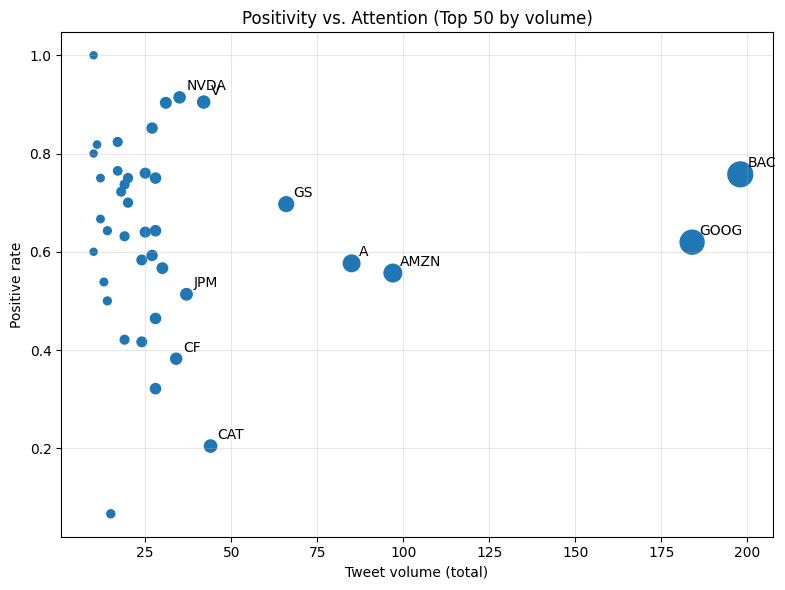

In [ ]:
# Scatter of volume vs positivity (bubble size = attention share)
top_scatter = tweet_summary.loc[tweet_summary['total']>=min_n].nlargest(50, 'total').copy()
plt.figure(figsize=(8,6))
sizes = 3000 * top_scatter['attention_share'] + 10  # bubble size
plt.scatter(top_scatter['total'], top_scatter['pos_share'], s=sizes)
plt.title('Positivity vs. Attention (Top 50 by volume)')
plt.xlabel('Tweet volume (total)')
plt.ylabel('Positive rate')
plt.grid(True, alpha=0.3)

for sym, row in top_scatter.nlargest(10, 'total').iterrows(): #we annotate some stocks
    plt.annotate(sym, (row['total'], row['pos_share']), xytext=(5,5), textcoords='offset points')
plt.tight_layout()
plt.show()


The scatter plot shows the relationship between tweet volume and positivity rate for the top 50 S&P 500 stocks by tweet volume between 2012 and 2020. The size of the dot is proportional to the total tweet volume for that stock. As one can see, famous stocks like Google and Bank of America Corporation are mentioned far more frequently than others, yet their positivity rates remain moderate (around 0.6–0.75). This suggests that **visibility does not necessarily correlate with more positive sentiment**, as popular tickers attract both bullish and bearish discussions.
**NVIDIA stands out with a very high positivity rate** (~0.9) despite relatively fewer mentions, implying strong investor optimism during the observed period.
On the opposite side, Caterpillar Inc. shows relatively low positivity rates, suggesting bearish or skeptical sentiment.
Overall, the graph demonstrates a weak or non-linear relationship between attention and sentiment: higher tweet volume does not imply higher positivity with **large and widely discussed stocks facing diverse opinions**, leading to a more moderate average sentiment.

## Negative Share as Media Attention

Here below we compute, for each stock, the **share of negative tweets** regarding that stock over the total amount of mentions. We do this because our final goal is to **test the effectiveness of negative share as a return predictor**.

Our choice of the factor related to Media Attention is supported by a broad body of financial literature on **loss aversion** (e.g., **Kahneman & Tversky, 1979**), which states that losses are perceived as roughly twice as impactful as equivalent gains. This phenomenon gives rise to a **behavioral asymmetry**, whereby **investors react more strongly to negative news than to positive ones**. For this reason we believe that, on Social Media, positive news often merely reinforce existing beliefs, while negative ones can trigger a revision of expectations or even panic selling.

In [ ]:
ts = tweet_summary.copy()

# We chose as measure of media attention the negative_share
ts['g'] = ts['neg_share']
min_support = 5
ts = ts.loc[ts['total'] >= min_support].copy()

# dividing the dataset into 10 groups based on negative share of tweets
# group 1 will contain stocks with lowest negative share, group 10 with highest
ts['decile'] = pd.qcut(ts['g'].rank(method='first'), q=10, labels=range(1,11)).astype(int)
groups = ts[['decile']].copy()

prices = df_web[['Date','Ticker','Adj Close']].dropna().copy()
prices['Date'] = pd.to_datetime(prices['Date'])
prices = prices.sort_values(['Ticker','Date'])
prices['return'] = prices.groupby('Ticker')['Adj Close'].pct_change()

merged = prices.merge(groups, left_on='Ticker', right_index=True, how='inner').dropna(subset=['return'])
portfolios = (merged.pivot_table(index='Date', columns='decile', values='return', aggfunc='mean')
                .sort_index())

# annualized return, volatility and sharpe ratio
ann_mean = portfolios.mean() * 252
ann_vol  = portfolios.std()  * np.sqrt(252)
sharpe   = np.where(ann_vol>0, ann_mean/ann_vol, np.nan)

# Correlation between return and neg_share
idx = ann_mean.index.astype(int)
corr = pd.Series(ann_mean.values, index=idx).corr(pd.Series(idx, index=idx), method='pearson')

print("Annualized mean return by decile (1=lowest neg-share ... 10=highest):")
display(pd.DataFrame({'ann_mean': ann_mean.round(4),
                      'ann_vol':  ann_vol.round(4),
                      'sharpe':   sharpe.round(3)}))
print(f"\n Correlation: {corr:.3f}")


Annualized mean return by decile (1=lowest neg-share ... 10=highest):


,ann_mean,ann_vol,sharpe
decile,,,
1,0.1560,0.1564,0.997
2,0.2059,0.2050,1.004
3,0.2361,0.2191,1.077
4,0.1751,0.2233,0.784
5,0.2548,0.1836,1.387
6,0.1846,0.1604,1.151
7,0.1910,0.2263,0.844
8,0.1636,0.1983,0.825
9,0.1394,0.1950,0.715



 Correlation: -0.419


After computing the **proportion of negative tweets for each stock**, we divided them into ten deciles (with decile 1 representing stocks with the lowest negativity and decile ten those with the highest negativity). Daily returns are then calculated for each stock and averaged within each decile to build ten sentiment-based portfolios (considering an equally weighted case everytime). We then computed annualized mean returns, volatility, and Sharpe ratios for a detailed  comparison of performance across sentiment groups.

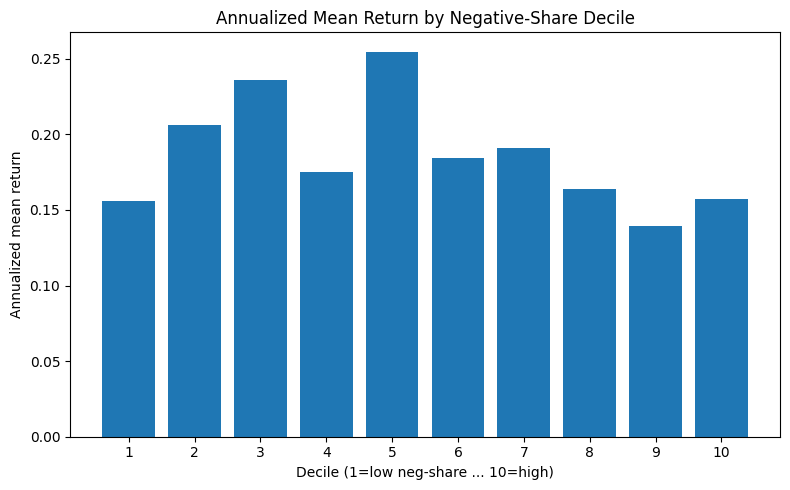

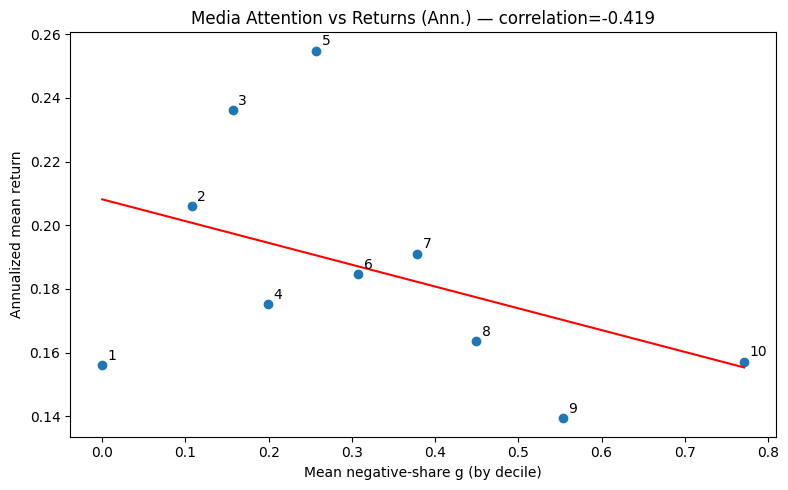

In [ ]:
# Plots
# bar plot
plt.figure(figsize=(8,5))
plt.bar(ann_mean.index.astype(str), ann_mean.values)
plt.title('Annualized Mean Return by Negative-Share Decile')
plt.xlabel('Decile (1=low neg-share ... 10=high)')
plt.ylabel('Annualized mean return'); plt.tight_layout(); plt.show()

# scatter plot
neg_share_by_decile = ts.groupby('decile')['g'].mean().sort_index()
annual_mean_by_decile = ann_mean.sort_index()

xy = pd.concat([neg_share_by_decile.rename('g_mean'), annual_mean_by_decile.rename('ann_mean')],axis=1).dropna()
plt.figure(figsize=(8,5))
plt.scatter(xy['g_mean'].values, xy['ann_mean'].values)
for d, (gx, ay) in zip(xy.index, xy[['g_mean','ann_mean']].to_numpy()):
    plt.annotate(str(d), (gx, ay), xytext=(4,4), textcoords='offset points')

m, b = np.polyfit(xy['g_mean'].to_numpy(), xy['ann_mean'].to_numpy(), 1)
xs = np.array([xy['g_mean'].to_numpy().min(), xy['g_mean'].to_numpy().max()])
ys = m*xs + b
plt.plot(xs, ys, color="red")

plt.xlabel('Mean negative-share g (by decile)')
plt.ylabel('Annualized mean return')
plt.title(f'Media Attention vs Returns (Ann.) — correlation={corr:.3f}')
plt.tight_layout(); plt.show()

As one can see from the graph above, there seems to be a **clear negative link between the share of negative tweets** (neg_share, our measure of media attention *g*) and the annualized mean return (ann_mean). The correlation of around -0.42 confirms that stocks attracting more negative attention on Twitter (those in higher deciles) tend to show lower returns, while those discussed in a more positive light generally perform better on average.
In simple terms, negativity on Twitter seems to matter: **stocks that are talked about more negatively often end up doing worse**.


These findings suggest that social media sentiment could have some predictive power over future performance. However, to really know if negative share is a meaningful factor in explaining returns, we need to perform further checks. More specifically, we must **verify the direction of the causality**: is a negative media attention contributing to a bad performance or is a bad performance driving bad tweets? Is the relationship among the two conditioned by a third omitted variable? This is what we want to verify in the section below with the Fama-French framwork.


###Optional: Testing Predictor Effectiveness

In the section below, we run a regression of the returns with the 5 factors illustrated by Fama-French in their famous framework (*Market excess return*, *Small Minus Big*, *High Minus Low*, *Robust Minus Weak*, and *Conservative Minus Aggressive*). Our aim is to **see if, after we account for these additional components, the relationship between returns and our factor (negative shares) still stands**.

In [ ]:
ff = pdr.DataReader('F-F_Research_Data_5_Factors_2x3_Daily', 'famafrench')[0].copy()
ff = ff.rename_axis('Date').reset_index()
if not np.issubdtype(ff['Date'].dtype, np.datetime64):
    ff['Date'] = pd.to_datetime(ff['Date'].astype(str))

fac_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
ff[fac_cols] = ff[fac_cols].astype(float) / 100.0
ff= ff[['Date', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']]

returns = prices[['Date','Ticker','return']].dropna().copy()

data = returns.merge(ff, on='Date', how='inner')
data['excess'] = data['return'] - data['RF']  # r_it - RF_t


def fit_ff5_residuals(g):
    cols = ['Mkt-RF','SMB','HML','RMW','CMA','excess']
    g = g.dropna(subset=cols).copy()
    X = sm.add_constant(g[['Mkt-RF','SMB','HML','RMW','CMA']], has_constant='add')
    y = g['excess']
    res = sm.OLS(y, X).fit()
    g['abnormal'] = res.resid
    g['alpha'] = res.params.get('const', np.nan)
    return g

resids = (data
          .groupby('Ticker', group_keys=False)
          .apply(fit_ff5_residuals))


# Redoing the portfolio construction, but using residuals instead of raw returns
# df 'groups' contains the portfolio each stock belongs to

resids2 = (resids
           .dropna(subset=['abnormal'])
           .merge(groups, left_on='Ticker', right_index=True, how='inner'))

portfolios_abn = (resids2
                  .pivot_table(index='Date', columns='decile', values='abnormal', aggfunc='mean')
                  .sort_index())

# Annualized abnormal return, volatility and sharpe ratio
ann_mean_abn = portfolios_abn.mean() * 252
ann_vol_abn  = portfolios_abn.std()  * np.sqrt(252)
sharpe_abn   = np.where(ann_vol_abn>0, ann_mean_abn/ann_vol_abn, np.nan)

# Correlation between decile index and abnormal mean
idx = ann_mean_abn.index.astype(int)
corr_abn = pd.Series(ann_mean_abn.values, index=idx).corr(pd.Series(idx, index=idx), method='pearson')
print(f"Corr (neg_share vs ann abnormal mean): {corr_abn:.3f}")

display(pd.DataFrame({'ann_mean_abn': ann_mean_abn.round(4),
                      'ann_vol_abn':  ann_vol_abn.round(4),
                      'sharpe_abn':   sharpe_abn.round(3)}))

/tmp/ipython-input-1621313540.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = pdr.DataReader('F-F_Research_Data_5_Factors_2x3_Daily', 'famafrench')[0].copy()
/tmp/ipython-input-1621313540.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fit_ff5_residuals))


Corr (neg_share vs ann abnormal mean): -0.064


,ann_mean_abn,ann_vol_abn,sharpe_abn
decile,,,
1,-0.0000,0.0922,-0.000
2,-0.0000,0.0836,-0.000
3,0.0010,0.1087,0.009
4,-0.0000,0.0949,-0.000
5,-0.0022,0.0907,-0.025
6,-0.0000,0.0813,-0.000
7,-0.0000,0.0923,-0.000
8,-0.0000,0.0762,-0.000
9,-0.0000,0.0981,-0.000


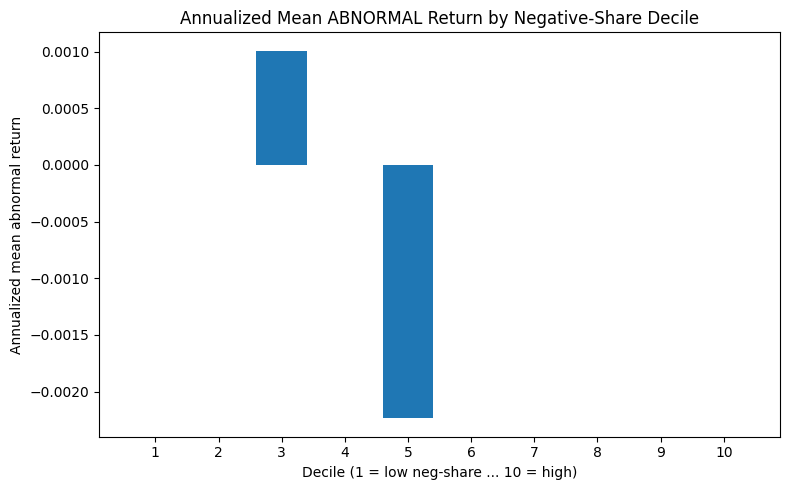

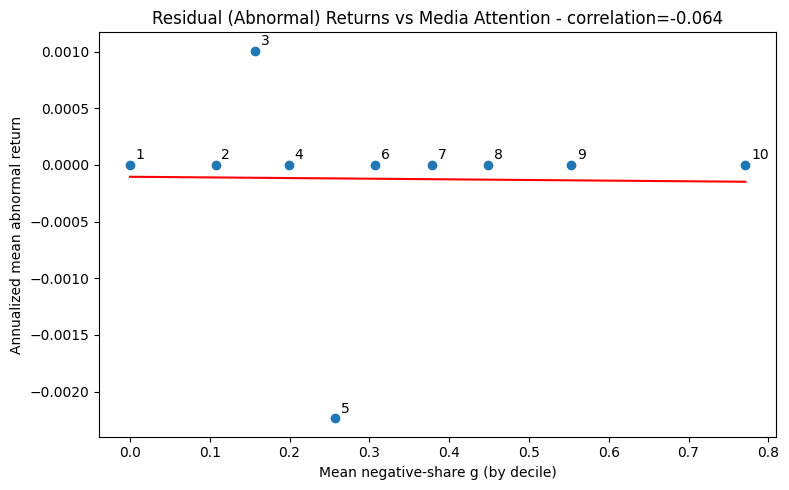

In [ ]:
# Plots
# Bar: Annualized mean abnormal return by neg_share
plt.figure(figsize=(8,5))
plt.bar(ann_mean_abn.index.astype(str), ann_mean_abn.values)
plt.title('Annualized Mean ABNORMAL Return by Negative-Share Decile')
plt.xlabel('Decile (1 = low neg-share ... 10 = high)')
plt.ylabel('Annualized mean abnormal return')
plt.tight_layout(); plt.show()

# Scatter: mean neg_share (by decile) vs annualized mean abnormal return
neg_share_by_decile = ts.groupby('decile')['g'].mean().sort_index()
xy_abn = pd.concat([neg_share_by_decile.rename('g_mean'),
                    ann_mean_abn.rename('ann_abn_mean')], axis=1).dropna()

plt.figure(figsize=(8,5))
plt.scatter(xy_abn['g_mean'].values, xy_abn['ann_abn_mean'].values)
for d, (gx, ay) in zip(xy_abn.index, xy_abn[['g_mean','ann_abn_mean']].to_numpy()):
    plt.annotate(str(d), (gx, ay), xytext=(4,4), textcoords='offset points')

m, b = np.polyfit(xy_abn['g_mean'].to_numpy(), xy_abn['ann_abn_mean'].to_numpy(), 1)
xs = np.array([xy_abn['g_mean'].min(), xy_abn['g_mean'].max()])
ys = m*xs + b
plt.plot(xs, ys, color = "red")

plt.xlabel('Mean negative-share g (by decile)')
plt.ylabel('Annualized mean abnormal return')
plt.title(f'Residual (Abnormal) Returns vs Media Attention - correlation={corr_abn:.3f}')
plt.tight_layout(); plt.show()

In the graph above we plotted the relationship between our factor (negative shares) and the residuals of the regression including the 5 factors by Fama-French. From a financial point of view, these residuals can be seen as a sort of **Annualized mean abnormal returns** on top of the one explained by our regression. As one can see, they are mostly around 0, meaning that the **relationship between negative shares and returns seems to disappear**. This is confirmed by the **very small magnitude (-0.064) of the correlation coefficient** among negative shares and the aforementioned residuals.

In [ ]:
BASE_FACTORS = ['Mkt-RF','SMB','HML','RMW','CMA']

def corr_leave_one_out(exclude=None):
    use_factors = [f for f in BASE_FACTORS if (exclude is None or f not in exclude)]
    cols = use_factors + ['excess']

    def fit_res(g):
        g = g.dropna(subset=cols).copy()
        X = sm.add_constant(g[use_factors], has_constant='add')
        y = g['excess']
        res = sm.OLS(y, X).fit()
        g['abnormal'] = res.resid
        return g

    resids = (data.groupby('Ticker', group_keys=False)
                    .apply(fit_res)
                    .dropna(subset=['abnormal'])
                    .merge(groups, left_on='Ticker', right_index=True, how='inner'))

    portfolios = (resids.pivot_table(index='Date', columns='decile',
                                     values='abnormal', aggfunc='mean')
                         .sort_index())

    ann_mean = portfolios.mean() * 252
    idx = ann_mean.index.astype(int)
    corr = pd.Series(ann_mean.values, index=idx).corr(pd.Series(idx, index=idx),
                                                      method='pearson')
    return corr

# Tabella riassuntiva: tutti i fattori vs esclusione di uno alla volta
rows = [{'spec': 'All factors', 'corr': round(corr_leave_one_out(None), 3)}]
rows += [{'spec': f'Exclude {f}', 'corr': round(corr_leave_one_out([f]), 3)}
         for f in BASE_FACTORS]

pd.DataFrame(rows)

/tmp/ipython-input-3189344754.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fit_res)
/tmp/ipython-input-3189344754.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fit_res)
/tmp/ipython-input-3189344754.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

,spec,corr
0,All factors,-0.064
1,Exclude Mkt-RF,-0.290
2,Exclude SMB,-0.092
3,Exclude HML,-0.171
4,Exclude RMW,-0.066
5,Exclude CMA,-0.057


To understand why the relationship between negative shares and returns seemed to disappear, we **computed the correlations** among the regression residuals and our factor, **each time excluding one factor from the model**. By doing so, we wanted to test whether any of the five Fama-French factors **overlapped in explanatory power** with the negative shares variable.

As shown in the table above, the **two factors most correlated** with our predictor are **Mkt and HML**. This finding suggests that the apparent link between negative Twitter sentiment and subsequent stock underperformance does not reflect a direct causal relationship. Instead, **both variables seem to respond to the same underlying market forces**. More in detail, in periods of weak market conditions or when value stocks underperform (captured by negative realizations of Mkt and HML, respectively), investors tend to express more negative opinions on social media, and stock returns are simultaneously lower. In other words, **negative sentiment and poor performance move together because they are joint outcomes** of broader dynamics.